In [1]:
import os
import json
import random
import shutil
import time
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as ticker
import seaborn as sns
import imagehash

from pathlib import Path
from PIL import Image
from collections import Counter

from tensorflow.keras import layers, Model
from tensorflow.keras.applications import MobileNetV3Large
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import train_test_split

IMG_SIZE = 224
BATCH_SIZE = 32

2026-05-04 21:47:28.167712: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777931248.191865    1359 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777931248.199561    1359 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777931248.219147    1359 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777931248.219172    1359 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777931248.219175    1359 computation_placer.cc:177] computation placer alr

## Step 1: Prepare Waste Classification Dataset

### 1.1 Download the Dataset

We will be using the [Recyclable and Household Waste Classification](https://www.kaggle.com/datasets/alistairking/recyclable-and-household-waste-classification) on Kaggle. The dataset contains 15,000 images (each 256 x 256 pixels) organized into 30 distinct classes of waste. Each class is further divided into 2 subcategories: `defualt` (studio-like images of waste items) and `real_world` (images of waste items in real-world environments). 

Each class contains 500 images. The images are evenly divided between the two subcategories for each class. 

In [2]:
# Download dataset from Kaggle
import kagglehub
path = kagglehub.dataset_download("alistairking/recyclable-and-household-waste-classification")
print(path)


# Declare and initalize global variable DATASET_PATH and SPLITS_PATH
DATASET_PATH = Path("/kaggle/input/datasets/alistairking/recyclable-and-household-waste-classification/images/images")
SPLITS_PATH  = Path("/kaggle/working/splits")

/kaggle/input/datasets/alistairking/recyclable-and-household-waste-classification


### 1.2 Set the Random Seed

In [3]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

### 1.3 Map Each Class of Waste to a Disposal Pathway

Each class of waste must be disposed differently. We will map each class of waste within the dataset to one of five disposal pathways: **garbage**, **curbside recycling**, **drop-off recycling** and **compost**. The United States has over 19,000 different municipalities. Each municipality has different recycling rules and guidelines. Therefore, it's impractical to make a disposal mapping for each class of waste that's universally applicable to all municipalities in the nation. Consequently, we will be using the recycling guidelines for the City of Phoenix in this project.

It is important to differentiate between curbside recycling and drop-off recycling. While both options only accept recyclable items, they do differ. For example, while plastic bags are recyclable, they do get disposed of in curbside recycling bins becuase they can damagae machinery at Material Recovery Facilities (MRFs). Instead, they should be disposed of in dropp-off recycling centers where they will be recycled using specialized processes. 


In [4]:
# Lists all classes within dataset
os.listdir(DATASET_PATH)

['plastic_soda_bottles',
 'aerosol_cans',
 'steel_food_cans',
 'disposable_plastic_cutlery',
 'cardboard_boxes',
 'glass_beverage_bottles',
 'plastic_cup_lids',
 'plastic_straws',
 'plastic_shopping_bags',
 'styrofoam_cups',
 'cardboard_packaging',
 'glass_food_jars',
 'styrofoam_food_containers',
 'eggshells',
 'aluminum_food_cans',
 'coffee_grounds',
 'plastic_food_containers',
 'food_waste',
 'magazines',
 'shoes',
 'clothing',
 'aluminum_soda_cans',
 'plastic_detergent_bottles',
 'newspaper',
 'tea_bags',
 'office_paper',
 'plastic_water_bottles',
 'paper_cups',
 'glass_cosmetic_containers',
 'plastic_trash_bags']

In [5]:
# Initializes a dictionary mapping each class of waste within the dataset to a disposal pathway
DISPOSAL_MAP = {

    # Curbside Recycling: 17 classes
    'plastic_soda_bottles':       'curbside_recycling',
    'aerosol_cans':               'curbside_recycling',
    'steel_food_cans':            'curbside_recycling',
    'cardboard_boxes':            'curbside_recycling',
    'glass_beverage_bottles':     'curbside_recycling',
    'plastic_cup_lids':           'curbside_recycling',
    'cardboard_packaging':        'curbside_recycling',
    'glass_food_jars':            'curbside_recycling',
    'aluminum_food_cans':         'curbside_recycling',
    'plastic_food_containers':    'curbside_recycling',
    'magazines':                  'curbside_recycling',
    'aluminum_soda_cans':         'curbside_recycling',
    'plastic_detergent_bottles':  'curbside_recycling',
    'newspaper':                  'curbside_recycling',
    'office_paper':               'curbside_recycling',
    'plastic_water_bottles':      'curbside_recycling',
    'glass_cosmetic_containers':  'curbside_recycling',

    # Drop-off Recycling: 4 classes
    'plastic_shopping_bags':      'dropoff_recycling',
    'plastic_trash_bags':         'dropoff_recycling',
    'clothing':                   'dropoff_recycling',
    'shoes':                      'dropoff_recycling',

    # Compsot: 4 classes
    'eggshells':                  'compost',
    'coffee_grounds':             'compost',
    'tea_bags':                   'compost',
    'food_waste':                 'compost',

    # Garbage: 5 classes
    'disposable_plastic_cutlery': 'garbage',
    'styrofoam_cups':             'garbage',
    'styrofoam_food_containers':  'garbage',
    'plastic_straws':             'garbage',
    'paper_cups':                 'garbage',
}

### 1.4 Display Class Distribution

With the disposal pathway map defined, we can now audit the dataset before splitting it. This cell looks up each class of waste's assigned disposal pathway from `DISPOSAL_MAP`, counts the number of images per class and calculates the percent composition of each class out of the total size of the dataset. It then displays the metrics for each class in a table and writes a csv to the `/kaggle/working`. 

In [6]:
# Appends each class of waste with disposal pathway and number of images into an empty array named records
records = []
for class_dir in sorted(DATASET_PATH.iterdir()):
    if not class_dir.is_dir():
        continue
    class_name = class_dir.name
    count = sum(1 for f in class_dir.rglob('*') if f.is_file())
    pathway = DISPOSAL_MAP.get(class_name, 'UNMAPPED')
    records.append({'class': class_name, 'count': count, 'pathway': pathway})

df = pd.DataFrame(records).sort_values('count', ascending=False)

# Calculate percent composition of each class out of total dataset size
df['pct'] = (df['count'] / df['count'].sum() * 100).round(2)

# Print table to output and write csv to /kaggle/working
print(df[['class', 'count', 'pct', 'pathway']].to_string(index=False))
df[['class', 'count', 'pct', 'pathway']].to_csv('/kaggle/working/class_distribution_table.csv', index=False)
print("\nSaved to /kaggle/working/class_distribution_table.csv")

                     class  count  pct            pathway
              aerosol_cans    500 3.33 curbside_recycling
        aluminum_food_cans    500 3.33 curbside_recycling
        aluminum_soda_cans    500 3.33 curbside_recycling
           cardboard_boxes    500 3.33 curbside_recycling
       cardboard_packaging    500 3.33 curbside_recycling
                  clothing    500 3.33  dropoff_recycling
            coffee_grounds    500 3.33            compost
disposable_plastic_cutlery    500 3.33            garbage
                 eggshells    500 3.33            compost
                food_waste    500 3.33            compost
    glass_beverage_bottles    500 3.33 curbside_recycling
 glass_cosmetic_containers    500 3.33 curbside_recycling
           glass_food_jars    500 3.33 curbside_recycling
                 magazines    500 3.33 curbside_recycling
                 newspaper    500 3.33 curbside_recycling
              office_paper    500 3.33 curbside_recycling
              

This cell plots the class distribution as a bar chart color coded by disposal pathway.

In [ ]:
# Initalize dictionary mapping disposal pathways to color for the legend
PATHWAY_COLORS = {
    'curbside_recycling': '#1565C0',
    'dropoff_recycling':  '#6A1B9A',
    'compost':            '#F57F17',
    'garbage':            '#2E7D32',
    'UNMAPPED':           '#B71C1C',
}

# Display class distribution in bar chart
fig, ax = plt.subplots(figsize=(20, 6))
ax.bar(df['class'], df['count'], width=0.5,
       color=[PATHWAY_COLORS.get(p, '#B71C1C') for p in df['pathway']],
       edgecolor='black', linewidth=0.8)

ax.set_xticks(range(len(df['class'])))
ax.set_xticklabels(df['class'], rotation=45, ha='right', fontsize=9)
ax.tick_params(axis='x', pad=10)

ax.set_xlabel('Classes of Waste', fontsize=11, labelpad=15)
ax.set_ylabel('Image Count', fontsize=11)
ax.set_title('Recyclable and Household Waste Dataset Class Distribution by Disposal Pathway', fontweight='bold', fontsize=13)

legend = ax.legend(
    handles=[mpatches.Patch(color=c, label=p.replace('_', ' ').title())
             for p, c in PATHWAY_COLORS.items() if p in df['pathway'].values],
    loc='upper left',
    bbox_to_anchor=(1.01, 1),
    borderaxespad=0,
    title='Legend',
    title_fontproperties={'weight': 'bold', 'size': 10},
    frameon=True,
    edgecolor='black',
    fancybox=False,
)
legend.get_frame().set_linewidth(2)

# Plot bar chart and save image to /kaggle/working
plt.tight_layout()
plt.savefig('/kaggle/working/class_distribution_bar_chart.png', dpi=150, bbox_inches='tight')
plt.show()

In this case we can see in both the table and the bar chart that all classes in the dataset have the same sample size (e.g. 500 images), so we don't have to worry about assigning class weights. 

### 1.5 Split Dataset into Train/Val/Test

To train our model we will split the dataset into three paths: **train (70%)**, **validation (15%)** and **test (15%)**

In [8]:
SPLITS_PATH = Path('data')

# Clear old splits if they exist
if SPLITS_PATH.exists():
    shutil.rmtree(SPLITS_PATH)
    print("Cleared old splits")

# Loop through all images in each class and assign to train, val, or test
for class_dir in sorted(DATASET_PATH.iterdir()):
    if not class_dir.is_dir():
        continue
    class_name = class_dir.name

    images = [f for f in class_dir.rglob('*') if f.is_file()]
    if len(images) < 10:
        print(f"WARNING: {class_name} only has {len(images)} images — skipping")
        continue

    train_imgs, temp    = train_test_split(images, test_size=0.30, random_state=SEED)
    val_imgs, test_imgs = train_test_split(temp,   test_size=0.50, random_state=SEED)

    for split, imgs in [('train', train_imgs), ('val', val_imgs), ('test', test_imgs)]:
        split_dir = SPLITS_PATH / split / class_name
        split_dir.mkdir(parents=True, exist_ok=True)
        for img in imgs:
            # Prefix with parent subfolder name to avoid filename collisions
            unique_name = f"{img.parent.name}_{img.name}"
            shutil.copy2(img, split_dir / unique_name)

# Print Splits
print("Train/val/test split complete")
print(f"  Train: {sum(1 for _ in (SPLITS_PATH/'train').rglob('*') if _.is_file())} images")
print(f"  Val:   {sum(1 for _ in (SPLITS_PATH/'val').rglob('*')   if _.is_file())} images")
print(f"  Test:  {sum(1 for _ in (SPLITS_PATH/'test').rglob('*')  if _.is_file())} images")

Cleared old splits
Train/val/test split complete
  Train: 10500 images
  Val:   2250 images
  Test:  2250 images


## Step 2: Train the Wast Classification Model

### 2.1 Load Split Dataset

Load the train, validation, and test splits from disk into TensorFlow datasets. All images are resized to 224×224 and grouped into batches of 32. Class names and count are extracted from the training split and used to configure the model output layer in Step 2.3.

The data pipeline is optimized for GPU training using three operations:
- **cache:** stores images in memory after the first epoch so they are not re-read from disk each epoch
- **shuffle:**  randomly reorders the training set each epoch so the model does not see classes in the same order
- **prefetch:**  loads the next batch on the CPU while the GPU trains on the current one, eliminating idle time between batches

Shuffling is applied to the training set only to prevent the model from learning patterns in the order of the data. The order the images appear in val and train have no affect on the final metrics, so images are shuffled in those sets.

In [9]:
AUTOTUNE = tf.data.AUTOTUNE

'''
Load split datasets (train/val/test) from disk to tensorflow dataframe
Images are resized to 224x244 pixels and grouped into batches of 32
'''

train_ds = tf.keras.utils.image_dataset_from_directory(
    str(SPLITS_PATH / 'train'),
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    seed=SEED,
    label_mode='int'
)
val_ds = tf.keras.utils.image_dataset_from_directory(
    str(SPLITS_PATH / 'val'),
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    seed=SEED,
    label_mode='int'
)
test_ds = tf.keras.utils.image_dataset_from_directory(
    str(SPLITS_PATH / 'test'),
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    seed=SEED,
    label_mode='int'
)


class_names = train_ds.class_names
NUM_CLASSES = len(class_names) # Sets number of neurons in Dense layer to 30
print(f"Number of classes: {NUM_CLASSES}")
print(f"Classes: {class_names}")

# Images are stored in memory after first epoch so they don't get re-read every time
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE) # Images shuffled in train set
val_ds   = val_ds.cache().prefetch(buffer_size=AUTOTUNE) # Loads next batch on CPU
test_ds  = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

Found 10500 files belonging to 30 classes.


I0000 00:00:1777931291.578517    1359 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Found 2250 files belonging to 30 classes.
Found 2250 files belonging to 30 classes.
Number of classes: 30
Classes: ['aerosol_cans', 'aluminum_food_cans', 'aluminum_soda_cans', 'cardboard_boxes', 'cardboard_packaging', 'clothing', 'coffee_grounds', 'disposable_plastic_cutlery', 'eggshells', 'food_waste', 'glass_beverage_bottles', 'glass_cosmetic_containers', 'glass_food_jars', 'magazines', 'newspaper', 'office_paper', 'paper_cups', 'plastic_cup_lids', 'plastic_detergent_bottles', 'plastic_food_containers', 'plastic_shopping_bags', 'plastic_soda_bottles', 'plastic_straws', 'plastic_trash_bags', 'plastic_water_bottles', 'shoes', 'steel_food_cans', 'styrofoam_cups', 'styrofoam_food_containers', 'tea_bags']


### 2.2 Apply Data Augmentation Techniques

We apply data augmentation techniques to the train set to prevent the model from overfitting. [Model Overfitting](https://en.wikipedia.org/wiki/Overfitting) occurs when the model learns the training data too well capturing and doesn't learn the underlying patters. This usually results in high accuracy on training data but low accuracy on val and test splits. To prevent overfitting for this we manipulate and distort the images using data augmentation to ensure the model learns underlying patterns of the training data.

| Technique | Parameter | Purpose |
|---|---|---|
| RandomRotation | ±60° | Randomly rotates training images by 60 degrees left or right |
| RandomZoom | ±20% | Randomly zooms in or out on the training image by 20% |
| RandomTranslation | ±15% | Randomly translates training images 15% left or right |
| RandomFlip | Horizontal and vertical | Randomly flips the training image horizontally or vertically |
| RandomBrightness | ±30% | Randomly increases or decreases lighting on training image by 20% |
| RandomContrast | ±30% | Randomly increases or decreases contrast on training image by 20% |

**Note:** Augmentation is applied during training becuase we're preventin the model from overfitting to the data in that phase. We will test the model on unmodified images through the val and test sets. 

In [10]:
data_augmentation = tf.keras.Sequential([
    layers.RandomRotation(factor=60/360),
    layers.RandomZoom(height_factor=0.2),
    layers.RandomTranslation(height_factor=0.15, width_factor=0.15),
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomBrightness(factor=0.3),
    layers.RandomContrast(factor=0.3),
], name="augmentation")

### 2.3 Build Stage A Base Waste Classifier

Rebuilds Stage A with two targeted changes to the classification head identified from the v1 error metrics in Step 2.6.

| Layer | Output Shape | Params | Purpose |
|---|---|---|---|
| InputLayer | (None, 224, 224, 3) | 0 | Defines the expected image dimensions to be 224×224 pixels across 3 RGB channels |
| Augmentation | (None, 224, 224, 3) | 0 | Applies random transformations from Step 2.2 during training only |
| MobileNetV3Large | (None, 7, 7, 960) | 2,996,352 | Pretrained feature extractor with ImageNet weights compresses each image into a 7×7 grid of 960 features |
| GlobalAveragePooling2D | (None, 960) | 0 | Collapses the 7×7×960 feature map into a flat 960-value vector by averaging each channel |
| Dropout | (None, 960) | 0 | Randomly zeros 50% of features during training. This is increased from 30% to reduce the overfitting observed in the original run |
| Dense (256, ReLU + L2) | (None, 256) | 246,016 | Learns a compressed 256-dimensional representation with L2 regularization (1e-4) to penalize large weights and improve generalization |
| Dense (30, Softmax) | (None, 30) | 7,710 | Outputs a probability distribution across all 30 waste classes |

In [24]:
def build_stage_a(num_classes):
    inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = data_augmentation(inputs)
    base_model = MobileNetV3Large(
        input_shape=(IMG_SIZE, IMG_SIZE, 3),
        include_top=False,          # Removes ImageNet Classification Head
        weights='imagenet',          # Loads ImageNet weights
        include_preprocessing=True   # Handles pixel normalization to 0-1 scale
    )
    base_model.trainable = False     # Freezes backbone parameters so only classification head is trained
    x = base_model(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)  # Collapses output to flat vector of 960 values by averaging color channels
    x = layers.Dropout(0.5)(x)              # Randomly turns off 50% of neurons to reduce overfitting
    x = layers.Dense(256, activation='relu',
                     kernel_regularizer=tf.keras.regularizers.l2(1e-4))(x)  # Compressed 256D representation with L2 regularization
    outputs = layers.Dense(num_classes, activation='softmax')(x)             # Produces probability distribution across all 30 waste classes
    model = Model(inputs, outputs, name="stage_a")
    return model, base_model

model_a, base_model = build_stage_a(NUM_CLASSES)
model_a.summary()

Model: "stage_a"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MobileNetV3Large (Functional)   │ (None, 7, 7, 960)      │     2,996,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 960)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 960)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       246,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 30)             │         7,710 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,250,078 (12.40 MB)

 Trainable params: 253,726 (991.12 KB)

 Non-trainable params: 2,996,352 (11.43 MB)

### 2.4 Define Traing Callbacks

Callbacks are objects that monitor training and automatically take actions at
the end of each epoch. Three callbacks are defined here and passed into every
`model.fit()` call in Step 2.5.

| Callback | Monitors | Action |
|---|---|---|
| ModelCheckpoint | val_accuracy | Saves model weights to disk whenever val_accuracy improves |
| EarlyStopping | val_accuracy | Stops training if val_accuracy does not improve for 5 consecutive epochs |
| ReduceLROnPlateau | val_loss | Halves the learning rate if val_loss does not improve for 3 consecutive epochs |

In [16]:
# Checks whether val_accuracy improved after every epoch
checkpoint_cb = ModelCheckpoint(
    'stage_a_best.keras',
    monitor='val_accuracy',
    save_best_only=True, # Overwrites stage_a_best.keras with best model weights
    verbose=1
)

# Stops training if val_accuracy does not improve for 5 consecutive epochs
early_stop_cb = EarlyStopping(
    monitor='val_accuracy',
    patience=5,
    restore_best_weights=True # Rolls model back to epoch with best weights
)

# Halves learning rate when val_loss stops improve for 3 consecutive epochs
reduce_lr_cb = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    verbose=1
)

### 2.5.2 Model Training 1 (Phase 1 and 2)

Trains Stage A across two progressive phases using the revised strategy identified from the original error metrics in Step 2.6. Phase 3 is dropped entirely as it produced no improvement and slightly worsened val loss in the original run, indicating the dataset cannot support unfreezing beyond the top
3 convolutional blocks.

1. **Phase 1 (20 epochs, lr=1e-3):** The entire backbone is frozen so only the 253,726 parameters in the classification head are updated. Extended from 12 to 20 epochs because the original run showed val accuracy still climbing at epoch 12 with no sign of plateauing, leaving accuracy gains on the table.

2. **Phase 2 (25 epochs, lr=1e-4):** Layers 0-138 remain frozen. Layers 139 onward (expanded_conv_12, expanded_conv_13, expanded_conv_14, and conv_1) are unfrozen. These are the highest-level semantic layers responsible for recognizing complex shapes and object-level features. Extended from 20 to 25 epochs to give EarlyStopping more room to find the true convergence point. Both EarlyStopping and ReduceLROnPlateau are active.

In [22]:
# Phase 1: Freeze MobileNet backbone and train classification head only
print("=== Phase 1 ===")
base_model.trainable = False
model_a.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
history_p1 = model_a.fit(
    train_ds,
    epochs=20,
    validation_data=val_ds,
    callbacks=[checkpoint_cb, reduce_lr_cb],
    verbose=1
)

# Phase 2: Unfreeze top 3 convolutional blocks of backbone
print("\n=== Phase 2 ===")
base_model.trainable = True
for layer in base_model.layers[:139]:
    layer.trainable = False
for layer in base_model.layers[139:]:
    layer.trainable = True
model_a.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
history_p2 = model_a.fit(
    train_ds,
    epochs=25,
    validation_data=val_ds,
    callbacks=[checkpoint_cb, early_stop_cb, reduce_lr_cb],
    verbose=1
)

=== Phase 1 ===
Epoch 1/20
328/329 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.3235 - loss: 2.5775
Epoch 1: val_accuracy improved from -inf to 0.70756, saving model to stage_a_best.keras
329/329 ━━━━━━━━━━━━━━━━━━━━ 22s 48ms/step - accuracy: 0.3242 - loss: 2.5742 - val_accuracy: 0.7076 - val_loss: 0.9680 - learning_rate: 0.0010
Epoch 2/20
328/329 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.5582 - loss: 1.4890
Epoch 2: val_accuracy improved from 0.70756 to 0.73289, saving model to stage_a_best.keras
329/329 ━━━━━━━━━━━━━━━━━━━━ 14s 43ms/step - accuracy: 0.5583 - loss: 1.4889 - val_accuracy: 0.7329 - val_loss: 0.8588 - learning_rate: 0.0010
Epoch 3/20
328/329 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.6074 - loss: 1.3493
Epoch 3: val_accuracy improved from 0.73289 to 0.74889, saving model to stage_a_best.keras
329/329 ━━━━━━━━━━━━━━━━━━━━ 14s 43ms/step - accuracy: 0.6074 - loss: 1.3493 - val_accuracy: 0.7489 - val_loss: 0.8142 - learning_rate: 0.0010
Epoch 4/20
328/329 ━━━━━

In [14]:
for i, layer in enumerate(base_model.layers):
    print(i, layer.name, "| trainable:", layer.trainable)

0 input_layer_2 | trainable: False
1 rescaling | trainable: False
2 conv | trainable: False
3 conv_bn | trainable: False
4 activation | trainable: False
5 expanded_conv_depthwise | trainable: False
6 expanded_conv_depthwise_bn | trainable: False
7 re_lu | trainable: False
8 expanded_conv_project | trainable: False
9 expanded_conv_project_bn | trainable: False
10 expanded_conv_add | trainable: False
11 expanded_conv_1_expand | trainable: False
12 expanded_conv_1_expand_bn | trainable: False
13 re_lu_1 | trainable: False
14 expanded_conv_1_depthwise_pad | trainable: False
15 expanded_conv_1_depthwise | trainable: False
16 expanded_conv_1_depthwise_bn | trainable: False
17 re_lu_2 | trainable: False
18 expanded_conv_1_project | trainable: False
19 expanded_conv_1_project_bn | trainable: False
20 expanded_conv_2_expand | trainable: False
21 expanded_conv_2_expand_bn | trainable: False
22 re_lu_3 | trainable: False
23 expanded_conv_2_depthwise | trainable: False
24 expanded_conv_2_depthwise

### 2.6 Plot Error Metrics

Plots training and validation accuracy and loss across both phases of the revised training strategy. The Phase 1 boundary is marked with a vertical dashed line.


1. **Accuracy:** Val accuracy plateaus around 81-82% before epoch 20, confirming Phase 1 runs to full convergence. Phase 2 drives a sustained improvement up to 85.42%, with the train/val gap opening gradually in later epochs.

2. **Loss:** Train and val loss converge steadily through both phases. Val loss stabilizes at ~0.57 by the end of Phase 2, with no signs of val loss increasing while train loss falls.

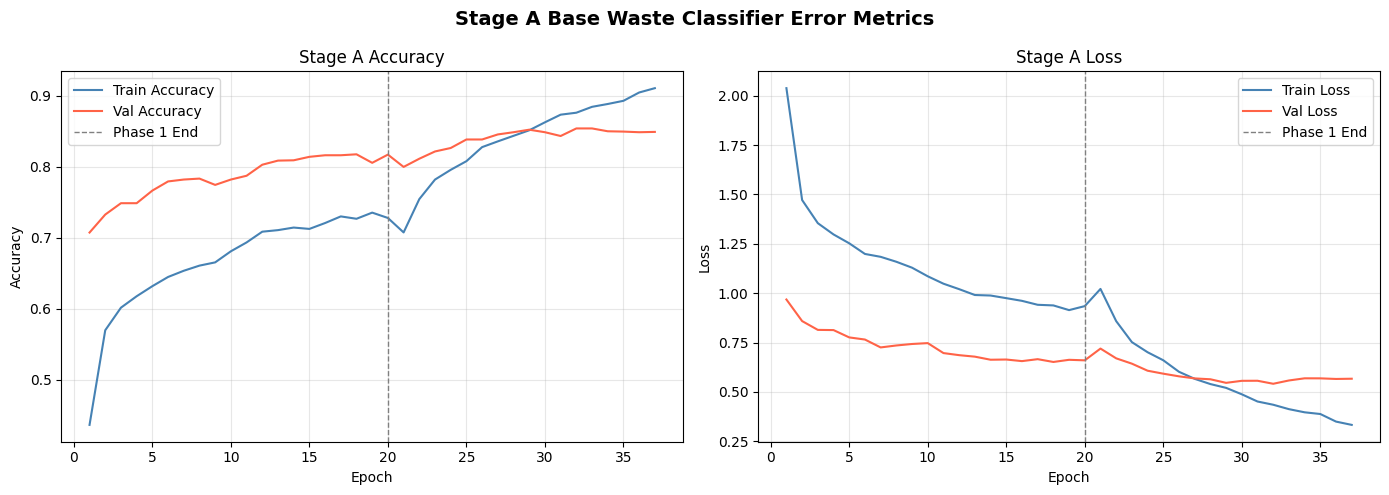

In [25]:
# Combine history across both phases
def combine_histories(histories):
    combined = {}
    for key in histories[0].history.keys():
        combined[key] = []
        for hist in histories:
            combined[key].extend(hist.history[key])
    return combined

history_v2 = combine_histories([history_p1, history_p2])
epochs = range(1, len(history_v2['accuracy']) + 1)

# Mark the end of Phase 1 on the plot
p1_end = len(history_p1.history['accuracy'])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot Stage A Accuracy
ax1.plot(epochs, history_v2['accuracy'],     label='Train Accuracy', color='steelblue')
ax1.plot(epochs, history_v2['val_accuracy'], label='Val Accuracy',   color='tomato')
ax1.axvline(x=p1_end, color='gray', linestyle='--', linewidth=1, label='Phase 1 End')
ax1.set_title('Stage A Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot Stage A Loss
ax2.plot(epochs, history_v2['loss'],     label='Train Loss', color='steelblue')
ax2.plot(epochs, history_v2['val_loss'], label='Val Loss',   color='tomato')
ax2.axvline(x=p1_end, color='gray', linestyle='--', linewidth=1, label='Phase 1 End')
ax2.set_title('Stage A Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle('Stage A Base Waste Classifier Error Metrics', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('stage_a_error_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

### 2.7 Evaluate Stage A Base Waste Classifier on Test Set

These cells evaluate the final Stage A model on the 2,250-image held-out test set across all 30 waste classes. Results are reported in descending order of per-class
accuracy.

| Metric | Score |
|---|---|
| Accuracy | 83.87% |
| Precision | 84.24% |
| Recall | 83.87% |
| F1 Score | 83.84% |


The model performs strongly across most classes, with 14 of 30 classes exceeding 90% accuracy. The top performing classes include coffee grounds (98.67%), food waste (97.33%), and disposable plastic cutlery (94.67%). These classes are visually
distinctive with little overlap with other classes. Performance is consistent across precision, recall, and F1 for most high-accuracy classes, indicating
the model is neither over-predicting nor under-predicting these categories. The bottom five classes tell a clear story about where the model struggles:

| Class | Accuracy | Likely Cause |
|---|---|---|
| steel_food_cans | 46.67% | High visual overlap with aluminum_food_cans |
| aluminum_food_cans | 65.33% | Confused with steel_food_cans in both directions |
| cardboard_boxes | 65.33% | Visual similarity with cardboard_packaging and newspaper |
| newspaper | 70.67% | Confused with office_paper and cardboard |
| paper_cups | 74.67% | Confused with styrofoam_cups and plastic_cup_lids |

Classification errors between visually similar classes within the same disposal
pathway  such as cardboard_boxes and cardboard_packaging, both mapped to curbside recycling  do not affect disposal routing accuracy. Errors that cross pathway boundaries, such as steel_food_cans being misclassified as aluminum_food_cans when they share the same route, are similarly benign. The critical errors for EcoBin are those where a misclassification sends an item to the wrong disposal pathway entirely, which is evaluated in the end-to-end routing accuracy reported in Step 6.

In [31]:
best_model_a = tf.keras.models.load_model('stage_a_best.keras')

all_preds, all_labels = [], []
for images, labels in test_ds:
    preds = best_model_a.predict(images, verbose=0)
    all_preds.extend(np.argmax(preds, axis=1))
    all_labels.extend(labels.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

# Compute per-class accuracy and sort descending
cm_report = confusion_matrix(all_labels, all_preds)
per_class_accuracy = cm_report.diagonal() / cm_report.sum(axis=1)
sorted_indices = np.argsort(per_class_accuracy)[::-1]
sorted_class_names = [class_names[i] for i in sorted_indices]

report = classification_report(
    all_labels, all_preds,
    target_names=class_names,
    digits=4,
    output_dict=True
)

# Print classification report organized by accuracy per class in descending order
print("Stage A Classification Report")
print("=" * 75)
print(f"{'Class':<35} {'Accuracy':>9} {'Precision':>10} {'Recall':>8} {'F1':>8} {'Support':>9}")
print("-" * 75)
for i in sorted_indices:
    name = class_names[i]
    acc  = per_class_accuracy[i]
    p    = report[name]['precision']
    r    = report[name]['recall']
    f1   = report[name]['f1-score']
    sup  = int(report[name]['support'])
    print(f"{name:<35} {acc:>9.4f} {p:>10.4f} {r:>8.4f} {f1:>8.4f} {sup:>9}")
print("-" * 75)
print(f"{'macro avg':<35} {np.mean(per_class_accuracy):>9.4f} {report['macro avg']['precision']:>10.4f} {report['macro avg']['recall']:>8.4f} {report['macro avg']['f1-score']:>8.4f} {int(report['macro avg']['support']):>9}")

Stage A Classification Report
Class                                Accuracy  Precision   Recall       F1   Support
---------------------------------------------------------------------------
coffee_grounds                         0.9867     0.9250   0.9867   0.9548        75
food_waste                             0.9733     0.9481   0.9733   0.9605        75
glass_food_jars                        0.9467     0.8256   0.9467   0.8820        75
disposable_plastic_cutlery             0.9467     0.9726   0.9467   0.9595        75
shoes                                  0.9467     0.9726   0.9467   0.9595        75
styrofoam_food_containers              0.9333     0.8537   0.9333   0.8917        75
plastic_trash_bags                     0.9200     0.8118   0.9200   0.8625        75
eggshells                              0.9200     0.8961   0.9200   0.9079        75
aerosol_cans                           0.9067     0.8500   0.9067   0.8774        75
magazines                              0.906

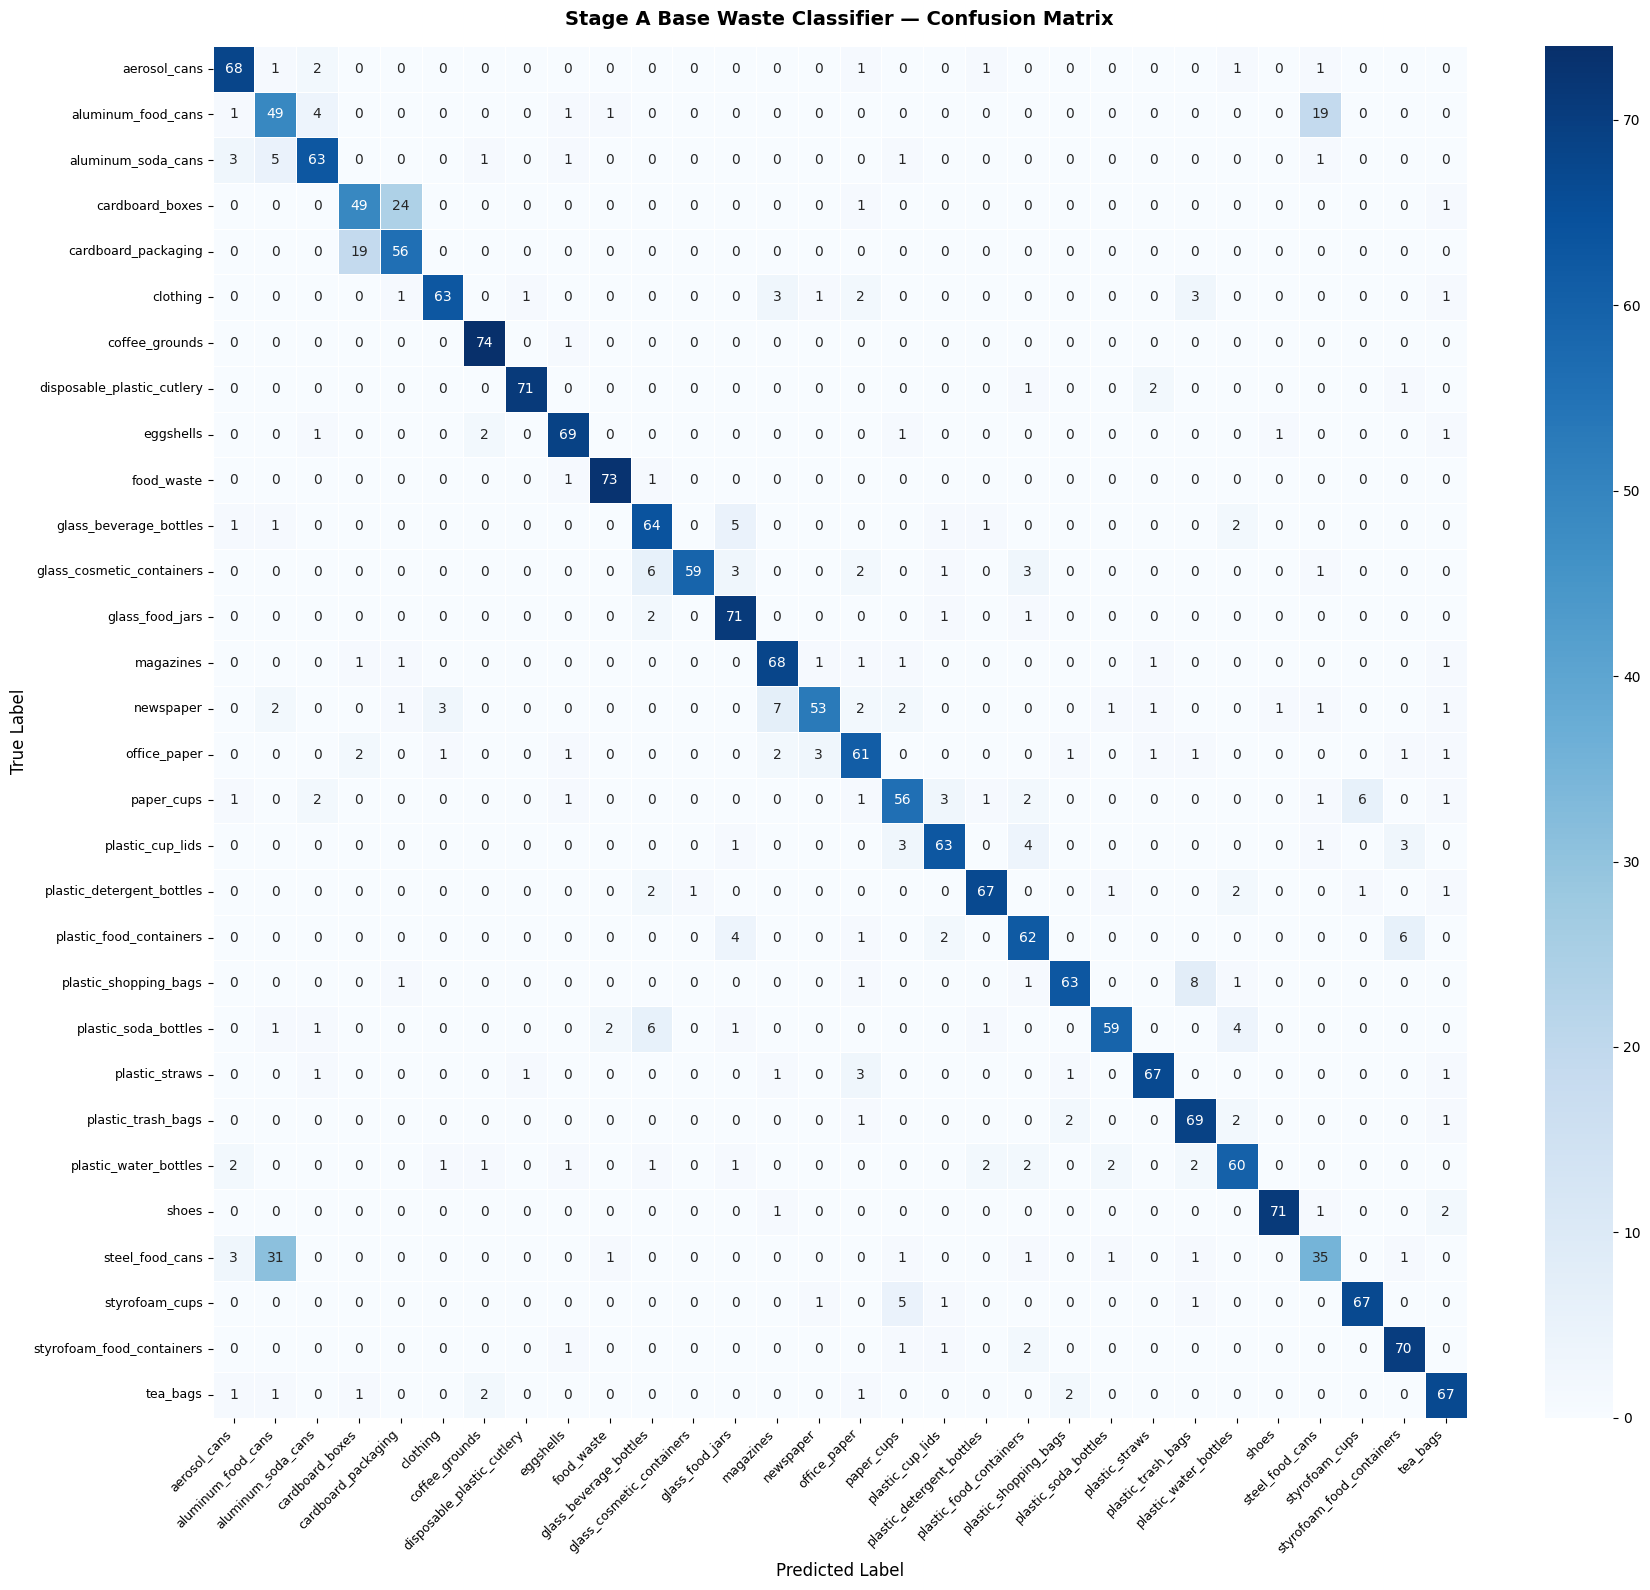

In [32]:
cm = confusion_matrix(all_labels, all_preds)

fig, ax = plt.subplots(figsize=(18, 16))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names,
    ax=ax,
    linewidths=0.5
)
ax.set_title('Stage A Base Waste Classifier — Confusion Matrix', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig('stage_a_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

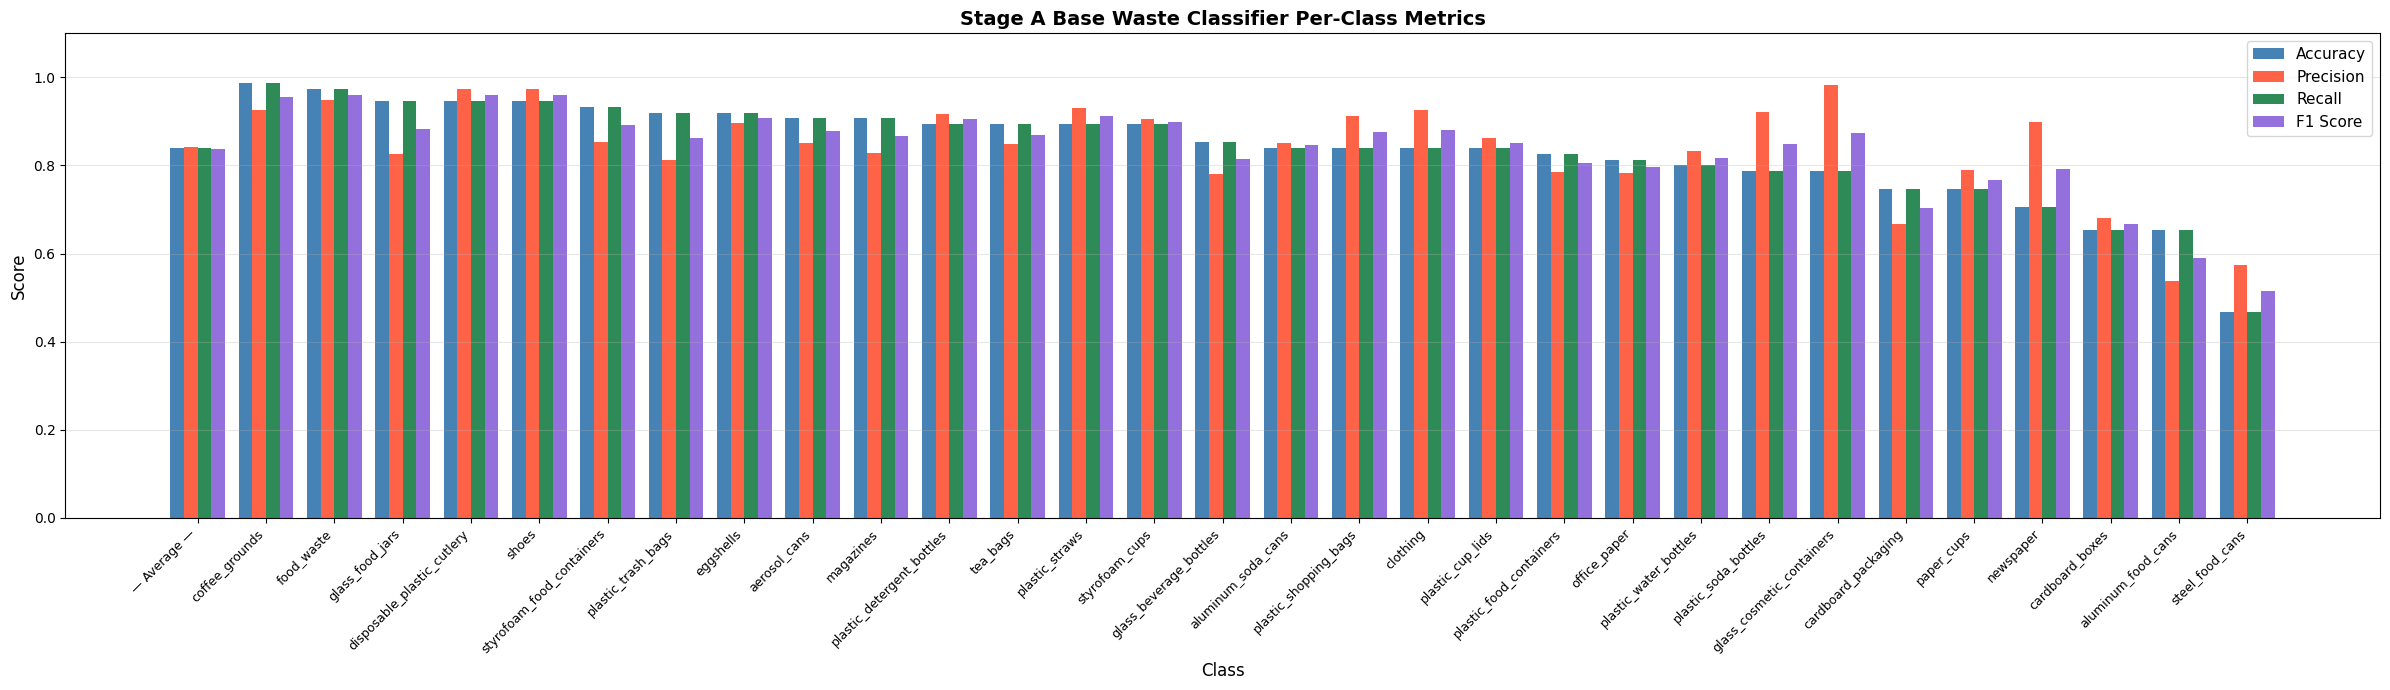


Overall Metrics
Accuracy:  0.8387
Precision: 0.8424
Recall:    0.8387
F1 Score:  0.8384


In [36]:
from sklearn.metrics import precision_score, recall_score, f1_score

per_class_accuracy  = cm.diagonal() / cm.sum(axis=1)
per_class_precision = precision_score(all_labels, all_preds, average=None, zero_division=0)
per_class_recall    = recall_score(all_labels, all_preds, average=None, zero_division=0)
per_class_f1        = f1_score(all_labels, all_preds, average=None, zero_division=0)

avg_accuracy  = np.mean(per_class_accuracy)
avg_precision = precision_score(all_labels, all_preds, average='macro', zero_division=0)
avg_recall    = recall_score(all_labels, all_preds, average='macro', zero_division=0)
avg_f1        = f1_score(all_labels, all_preds, average='macro', zero_division=0)

# Sort classes by descending accuracy, average bar first
sorted_indices     = np.argsort(per_class_accuracy)[::-1]
sorted_labels      = ['— Average —'] + [class_names[i] for i in sorted_indices]
sorted_accuracy    = [avg_accuracy]  + [per_class_accuracy[i]  for i in sorted_indices]
sorted_precision   = [avg_precision] + [per_class_precision[i] for i in sorted_indices]
sorted_recall      = [avg_recall]    + [per_class_recall[i]    for i in sorted_indices]
sorted_f1          = [avg_f1]        + [per_class_f1[i]        for i in sorted_indices]

x     = np.arange(len(sorted_labels))
width = 0.2

fig, ax = plt.subplots(figsize=(24, 7))
ax.bar(x - 1.5*width, sorted_accuracy,  width, label='Accuracy',  color='steelblue')
ax.bar(x - 0.5*width, sorted_precision, width, label='Precision', color='tomato')
ax.bar(x + 0.5*width, sorted_recall,    width, label='Recall',    color='seagreen')
ax.bar(x + 1.5*width, sorted_f1,        width, label='F1 Score',  color='mediumpurple')

ax.set_title('Stage A Base Waste Classifier Per-Class Metrics', fontsize=14, fontweight='bold')
ax.set_xlabel('Class', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(sorted_labels, rotation=45, ha='right', fontsize=9)
ax.set_ylim(0, 1.1)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('stage_a_per_class_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nOverall Metrics")
print(f"{'='*40}")
print(f"Accuracy:  {avg_accuracy:.4f}")
print(f"Precision: {avg_precision:.4f}")
print(f"Recall:    {avg_recall:.4f}")
print(f"F1 Score:  {avg_f1:.4f}")